### Display the image

Use the histogram of brightness. Range of 1.4 sigma seems to give a good coverage of brightness. 

Center (mean): 7913.33
Sigma (std):   3217.16
Display range: [5661.32, 10165.34]  (center ± 0.7·sigma)
Total width:   1.40·sigma


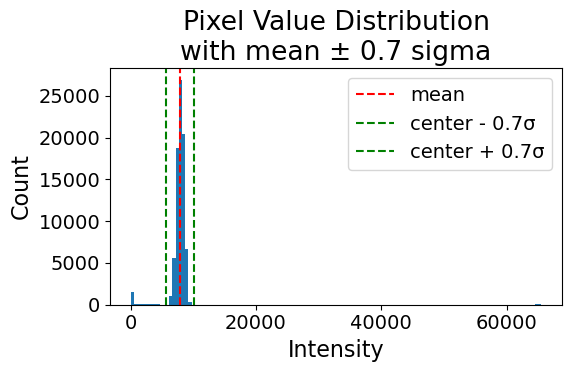

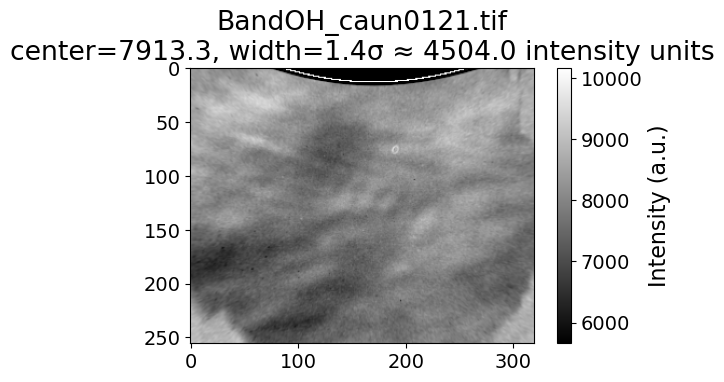

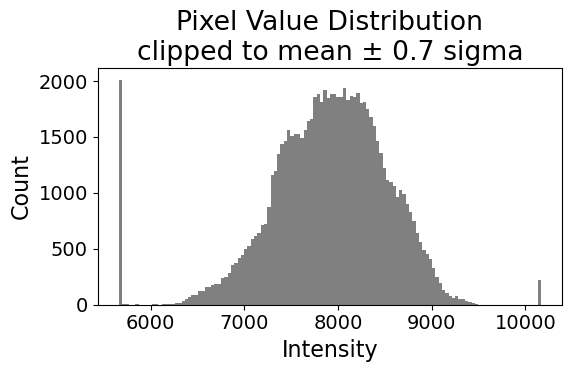

In [27]:
import numpy as np
import matplotlib.pyplot as plt
import tifffile as tiff

path = r"C:\Users\domin\juwavelet\examples\Waves For Anh\Sep14th527\BandOH_caun0121.tif"

img = tiff.imread(path)  # uint16, (256, 320)
arr = img.astype(np.float32)  # safer for statistics and normalization

# Flatten for statistics
sample = arr.ravel()

# Basic statistics
center = float(np.mean(sample))
sigma = float(np.std(sample))

# Use a range with total width 1.4 sigma (center ± 0.7 sigma)
factor = 0.7
vmin = center - factor * sigma
vmax = center + factor * sigma

print(f"Center (mean): {center:.2f}")
print(f"Sigma (std):   {sigma:.2f}")
print(f"Display range: [{vmin:.2f}, {vmax:.2f}]  (center ± {factor}·sigma)")
print(f"Total width:   {2*factor:.2f}·sigma")

# Histogram of raw data
plt.figure(figsize=(6, 4))
plt.hist(sample, bins=128)
plt.axvline(center, color="r", linestyle="--", label="mean")
plt.axvline(vmin, color="g", linestyle="--", label=f"center - {factor}σ")
plt.axvline(vmax, color="g", linestyle="--", label=f"center + {factor}σ")
plt.xlabel("Intensity")
plt.ylabel("Count")
plt.title(f"Pixel Value Distribution\nwith mean ± {factor} sigma")
plt.legend()
plt.tight_layout()
plt.show()
plt.close()

# Image using mean ± 0.7 sigma for display
plt.figure(figsize=(6, 4))
plt.imshow(np.clip(arr, vmin, vmax), cmap="gray", vmin=vmin, vmax=vmax)
plt.colorbar(label="Intensity (a.u.)")
plt.title(
    "BandOH_caun0121.tif\n"
    f"center={center:.1f}, width={2*factor:.1f}σ ≈ {2*factor*sigma:.1f} intensity units"
)
plt.tight_layout()
plt.show()
plt.close()

# Histogram of data clipped to mean ± 0.7 sigma
cleaned = np.clip(arr, vmin, vmax).ravel()

plt.figure(figsize=(6, 4))
plt.hist(cleaned, bins=128, color="gray")
plt.xlabel("Intensity")
plt.ylabel("Count")
plt.title(f"Pixel Value Distribution\nclipped to mean ± {factor} sigma")
plt.tight_layout()
plt.show()
plt.close()


### Apply decompose2d

Because of slicing, the SDTEV changed. So I adjust the range to +- 4 sigma. 

Center (mean): 8008.42
Sigma (std):   530.62
Dynamic range: [5885.95, 10130.89] = mean ± 4.00·sigma
In-range count: 58240
In-range min/max: 6039.00 / 9581.00
In-range mean/std: 8008.42 / 530.62
In-range percentiles 5/50/95: 7113.00 / 8046.00 / 8853.00
------------
cluster= 0
amplitude= 0.361823944892238 idx= (np.int64(4), np.int64(11), np.int64(64), np.int64(45))
selected elements: 135272
------------
cluster= 1
amplitude= 0.3549698536683646 idx= (np.int64(12), np.int64(7), np.int64(250), np.int64(111))
selected elements: 284774
------------
cluster= 2
amplitude= 0.3409259271454502 idx= (np.int64(8), np.int64(7), np.int64(128), np.int64(140))
selected elements: 129571
------------
cluster= 3
amplitude= 0.3407205285069152 idx= (np.int64(21), np.int64(8), np.int64(64), np.int64(116))
selected elements: 1184494
------------
cluster= 4
amplitude= 0.32422408035224787 idx= (np.int64(6), np.int64(9), np.int64(193), np.int64(52))
selected elements: 80244
------------
cluster= 5
amplitude= 0.32

100%|██████████████████████████████████████████████████████████████████████████████████| 20/20 [00:00<00:00, 60.48it/s]


Top wave 1 (idx=0): amp=0.362, lamx=-33.08, lamy=12.04, lam=11.31
Top wave 2 (idx=1): amp=0.355, lamx=66.16, lamy=24.08, lam=22.63
Top wave 3 (idx=2): amp=0.341, lamx=46.78, lamy=17.03, lam=16.00
Top wave 4 (idx=3): amp=0.341, lamx=284.20, lamy=50.11, lam=49.35
Top wave 5 (idx=4): amp=0.324, lamx=219726090060038048.00, lamy=13.45, lam=13.45


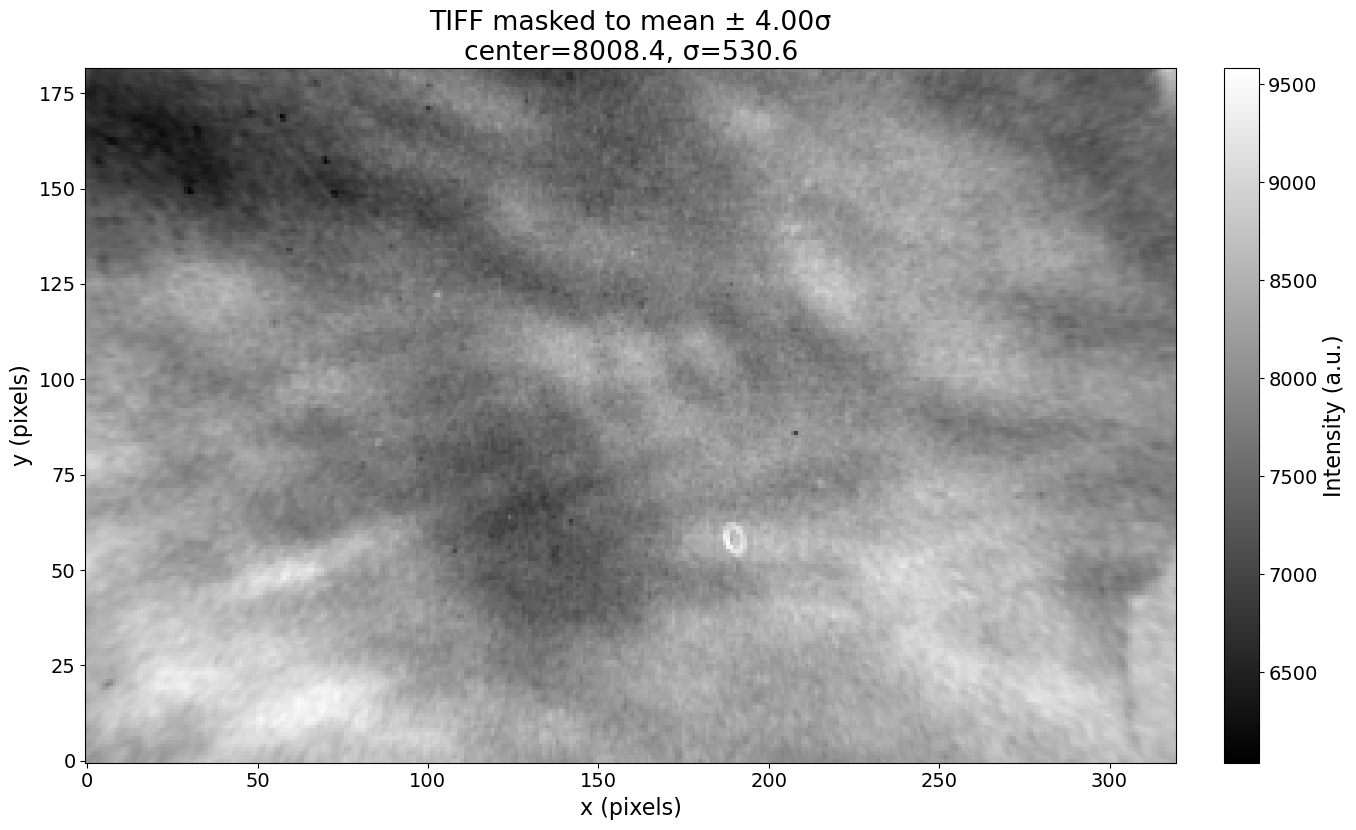

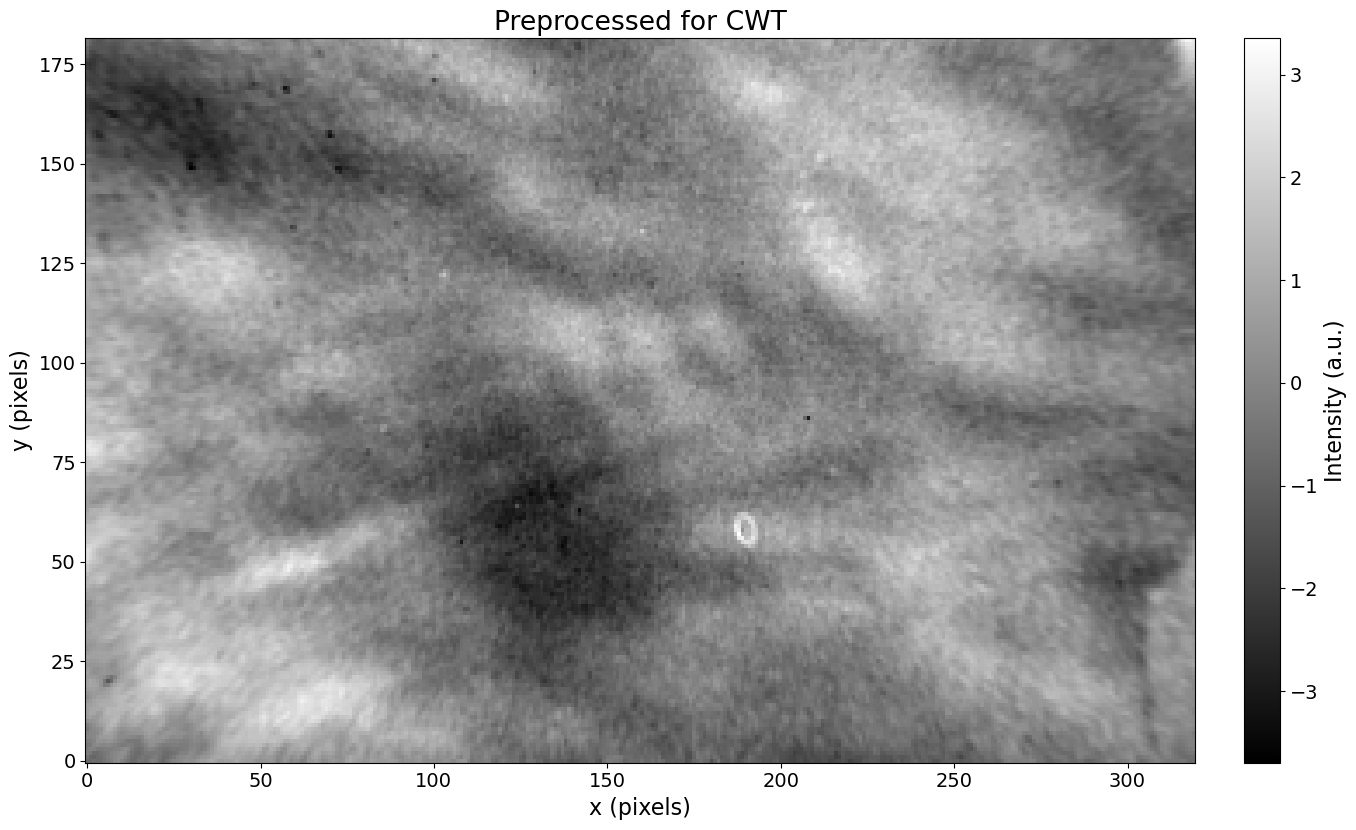

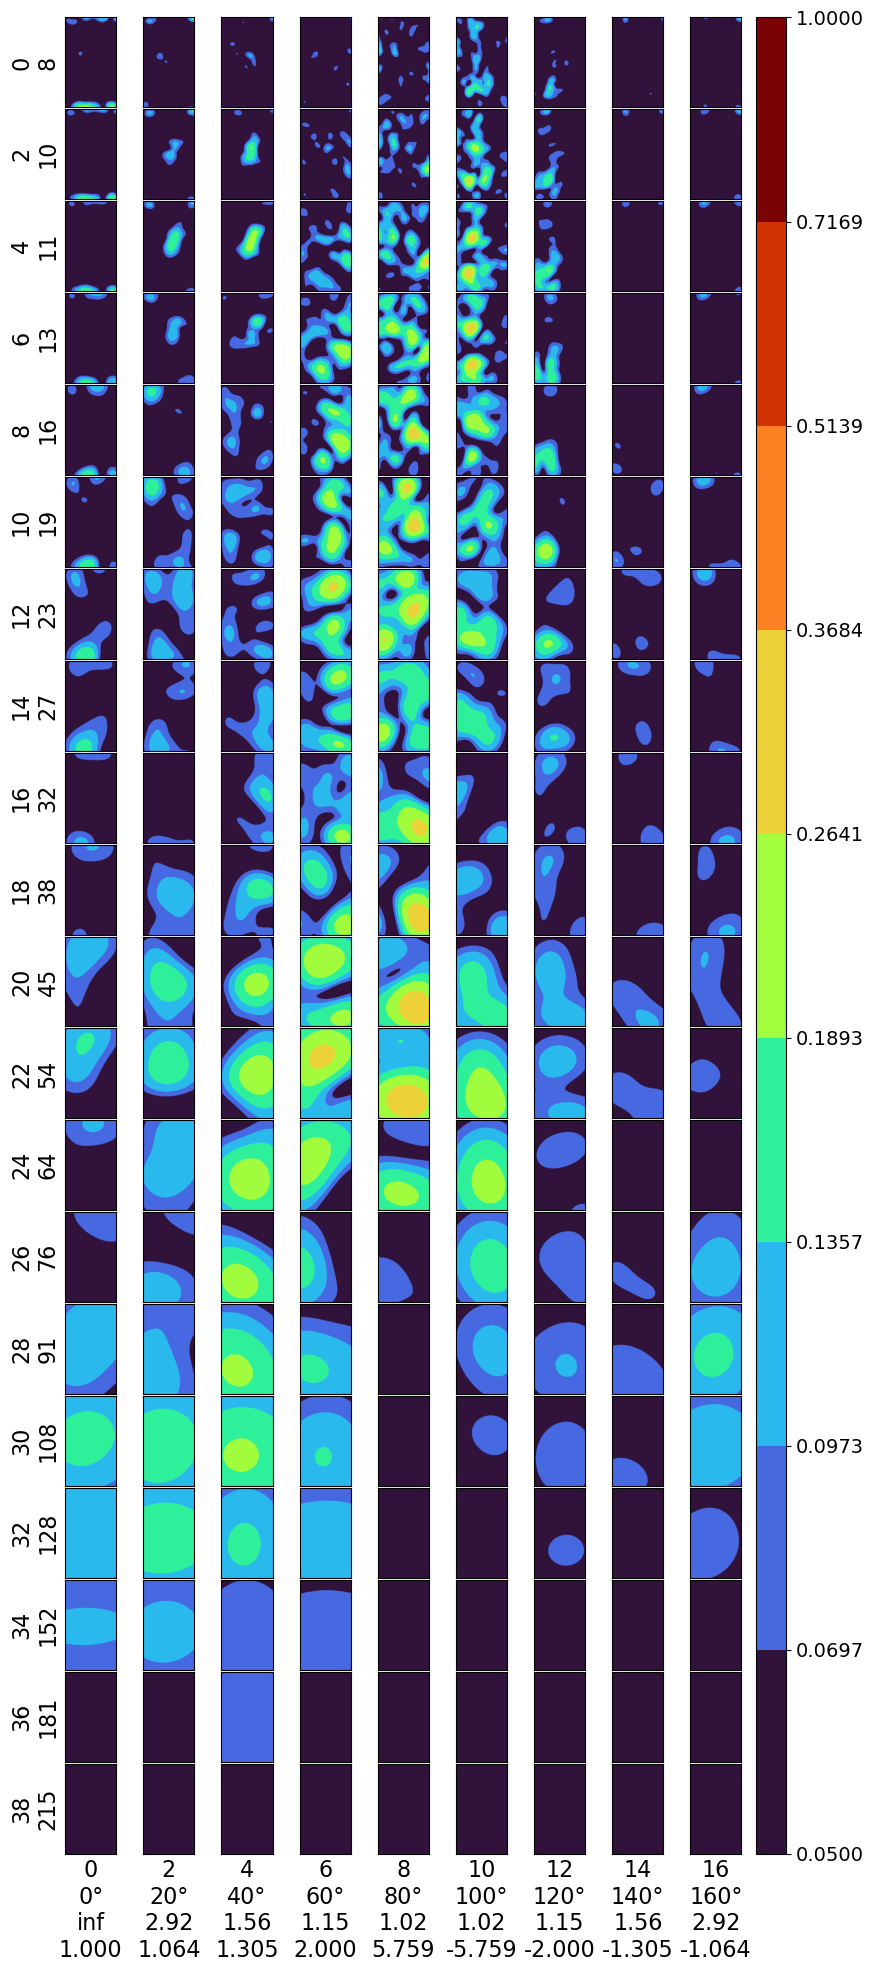

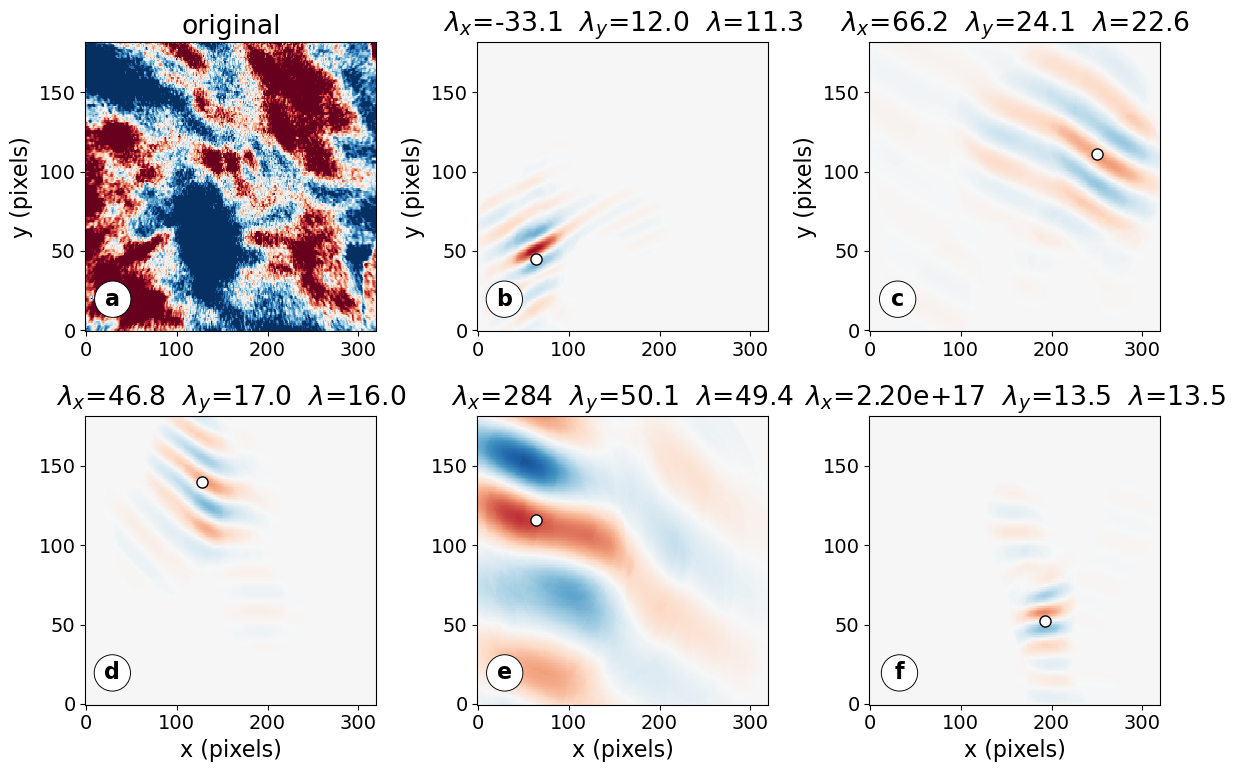

In [37]:
# example_decompose2d_from_tiff_rangefilter_top5.py
# Load a 16-bit TIFF, optionally mask values outside mean ± k·sigma for stats/preview,
# fill masked values for CWT, run juwavelet 2D CWT, and plot:
#   (a) original
#   (b–f) top 5 waves by cluster amplitude (if available)

from __future__ import annotations
import string
from typing import Tuple, Optional, List

import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import tifffile as tiff

from juwavelet import transform, utils

# --------------------------
# User params
# --------------------------
TIFF_PATH = r"C:\Users\domin\juwavelet\examples\Waves For Anh\Sep14th527\BandOH_caun0121.tif"

# ROI (pixel slices). Set to None to use full image.
X_SLICE: Optional[slice] = None
Y_SLICE: Optional[slice] = slice(18, 200)

# Range filter: use mean ± k·sigma instead of fixed [6000, 10000]
APPLY_RANGE_FILTER = True
RANGE_SIGMA_FACTOR = 4   # k in mean ± k·sigma

# How to fill invalid pixels before CWT (to keep rectangular grid)
# choices: "median", "mean", "zero"
FILL_INVALID_FOR_CWT = "median"

# Preprocessing
REMOVE_TREND = True        # subtract 2D plane
STANDARDIZE = True         # z-score to unit variance
GAUSS_BLUR_SIGMA = 0.0     # 0 disables, else e.g., 0.8

# Wavelet params
S0 = 8
DJ = 1/8
JS = 40
JT = 18
ASPECT = 1

# Pixel spacing (update if known)
DX = .623
DY = .623

# --------------------------
# Plot style
# --------------------------
matplotlib.rcParams.update({
    "axes.labelsize": 16,
    "font.size": 16,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "legend.fontsize": 14,
    "figure.figsize": [2 * 6.94, 2 * 4.29],
})

# --------------------------
# Helpers
# --------------------------
def load_tiff_window(
    path: str,
    xsl: Optional[slice],
    ysl: Optional[slice],
) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    """Return (x_coords, y_coords, window) where window is float32 with shape (ny, nx)."""
    img = tiff.imread(path)
    if img.ndim == 3 and img.shape[-1] == 1:
        img = img[..., 0]
    if img.ndim != 2:
        raise ValueError(f"Expected single-frame 2D TIFF; got shape {img.shape}")

    Z = np.asarray(img, dtype=np.float32)

    if ysl is None:
        ysl = slice(None, None)
    if xsl is None:
        xsl = slice(None, None)
    win = Z[ysl, xsl]

    ny, nx = win.shape
    x = np.arange(nx, dtype=float)
    y = np.arange(ny, dtype=float)

    # Clean improbable NaNs/Infs
    med = float(np.median(win))
    win = np.nan_to_num(win, nan=med, posinf=med, neginf=med).astype(np.float32, copy=False)
    return x, y, win

def make_range_mask(Z: np.ndarray, lo: float, hi: float) -> np.ndarray:
    """True where value is inside [lo, hi]."""
    return (Z >= lo) & (Z <= hi)

def detrend_plane(Z: np.ndarray) -> np.ndarray:
    ny, nx = Z.shape
    yy, xx = np.mgrid[0:ny, 0:nx]
    G = np.stack([xx.ravel(), yy.ravel(), np.ones(nx * ny)], axis=1)
    coeff, *_ = np.linalg.lstsq(G, Z.ravel(), rcond=None)
    plane = (coeff[0] * xx + coeff[1] * yy + coeff[2])
    return Z - plane

def maybe_blur(Z: np.ndarray, sigma: float) -> np.ndarray:
    if sigma <= 0:
        return Z
    try:
        from scipy.ndimage import gaussian_filter
    except Exception:
        return Z
    return gaussian_filter(Z, sigma=float(sigma))

def quicklook_pcolor(x1d: np.ndarray, y1d: np.ndarray, Z: np.ndarray, title: str, cmap="gray") -> None:
    fig, ax = plt.subplots()
    im = ax.pcolormesh(x1d, y1d, Z, shading="auto", cmap=cmap)
    cb = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cb.set_label("Intensity (a.u.)")
    ax.set_xlabel("x (pixels)")
    ax.set_ylabel("y (pixels)")
    ax.set_title(title)
    plt.tight_layout()

def fill_invalid(Z: np.ndarray, valid_mask: np.ndarray, how: str) -> np.ndarray:
    """Fill invalid pixels to keep rectangular grid before CWT."""
    out = Z.copy()
    inv = ~valid_mask
    if not np.any(inv):
        return out
    if how == "median":
        val = float(np.median(out[~inv])) if np.any(~inv) else float(np.median(out))
    elif how == "mean":
        val = float(np.mean(out[~inv])) if np.any(~inv) else float(np.mean(out))
    elif how == "zero":
        val = 0.0
    else:
        raise ValueError("FILL_INVALID_FOR_CWT must be 'median', 'mean', or 'zero'")
    out[inv] = val
    return out

def _fmt(v: float) -> str:
    if not np.isfinite(v):
        return "∞"
    v = float(v)
    if abs(v) >= 1000 or abs(v) < 0.1:
        return f"{v:.2e}"
    elif abs(v) >= 100:
        return f"{v:.0f}"
    else:
        return f"{v:.1f}"

# --------------------------
# Pipeline
# --------------------------
def run_pipeline():
    # Load TIFF window
    x1d, y1d, raw = load_tiff_window(TIFF_PATH, X_SLICE, Y_SLICE)

    # Compute mean/std and dynamic range: mean ± k·sigma
    sample = raw.ravel().astype(float)
    center = float(np.mean(sample))
    sigma = float(np.std(sample))
    k = RANGE_SIGMA_FACTOR
    lo = center - k * sigma
    hi = center + k * sigma

    print(f"Center (mean): {center:.2f}")
    print(f"Sigma (std):   {sigma:.2f}")
    print(f"Dynamic range: [{lo:.2f}, {hi:.2f}] = mean ± {k:.2f}·sigma")

    # Range filter: masked preview + stats
    mask = None
    if APPLY_RANGE_FILTER:
        mask = make_range_mask(raw, lo, hi)
        preview = raw.copy().astype(float)
        preview[~mask] = np.nan

        vals = preview[np.isfinite(preview)]
        if vals.size > 0:
            print(f"In-range count: {vals.size}")
            print(f"In-range min/max: {np.nanmin(vals):.2f} / {np.nanmax(vals):.2f}")
            print(f"In-range mean/std: {np.nanmean(vals):.2f} / {np.nanstd(vals):.2f}")
            p5, p50, p95 = np.nanpercentile(vals, [5, 50, 95])
            print(f"In-range percentiles 5/50/95: {p5:.2f} / {p50:.2f} / {p95:.2f}")
        else:
            print("Warning: no pixels within mean ± k·sigma")

        # Display: clip to [lo, hi], no 1–99% stretch
        disp = np.clip(preview, lo, hi)
        quicklook_pcolor(
            x1d,
            y1d,
            disp,
            f"TIFF masked to mean ± {k:.2f}σ\ncenter={center:.1f}, σ={sigma:.1f}",
        )
    else:
        # No masking, just clip for display
        disp = np.clip(raw, lo, hi)
        quicklook_pcolor(
            x1d,
            y1d,
            disp,
            f"TIFF raw, display mean ± {k:.2f}σ\ncenter={center:.1f}, σ={sigma:.1f}",
        )

    # Prepare data for CWT: fill removed pixels to keep rectangular grid
    filled = fill_invalid(raw, mask, FILL_INVALID_FOR_CWT) if APPLY_RANGE_FILTER and mask is not None else raw

    # Preprocess for CWT
    proc = filled.copy()
    if REMOVE_TREND:
        proc = detrend_plane(proc)
    if STANDARDIZE:
        m = np.median(proc)
        s = np.std(proc)
        proc = (proc - m) / s if s > 0 else (proc - m)
    proc = maybe_blur(proc, GAUSS_BLUR_SIGMA)

    quicklook_pcolor(x1d, y1d, proc, "Preprocessed for CWT")

    # juwavelet expects (nx, ny); image is (ny, nx)
    wave_xy = proc.T

    cwt = transform.decompose2d(
        wave_xy, dx=DX, dy=DY, s0=S0, dj=DJ, js=JS, jt=JT, aspect=ASPECT
    )

    # Identify clusters
    # amps: sequence of amplitudes per cluster; idxs: list of (scale_idx, theta_idx, ...)
    # iwave: per-(scale,theta)-component label image
    amps, idxs, iwave = utils.identify_cluster2d(cwt, min_amp=0.25, thr=0.15)

    decomposition, period, theta = [cwt[k] for k in ("decomposition", "period", "theta")]
    orig = decomposition.copy()

    # Overview CWT plot
    cmap = matplotlib.cm.turbo
    norm = matplotlib.colors.BoundaryNorm(
        np.exp(np.linspace(np.log(0.05), np.log(1.0), 10)), cmap.N
    )
    fig1, _ = utils.plot_decomposition2d(cwt, redux_s=2, redux_t=2, cmap=cmap, norm=norm)

    # ---- PLOT: original + top 5 waves by amplitude ----
    # Arrange in 2x3 = 6 panels: (0) original, (1..5) top waves
    fig, axs = plt.subplots(2, 3, figsize=(12, 8))
    axs = axs.flatten()

    opts_img = {"cmap": "RdBu_r", "vmin": -1, "vmax": 1, "rasterized": True}

    # (a) original
    axs[0].set_title("original")
    axs[0].pcolormesh(x1d, y1d, proc, **opts_img)

    # Determine top-K wave indices by amplitude
    K = 5
    if isinstance(amps, (list, tuple, np.ndarray)) and len(amps) > 0:
        amps = np.asarray(amps, dtype=float)
        order = np.argsort(amps)[::-1]  # descending
        top_idx_list: List[int] = [int(i) for i in order[:K] if i < len(idxs)]
    else:
        top_idx_list = []

    # For each top wave: reconstruct and display
    for k, wave_idx in enumerate(top_idx_list, start=1):
        ax = axs[k]
        # mask everything except this wave
        decomposition[:] = orig
        decomposition[iwave != wave_idx] = 0
        rec = transform.reconstruct2d(cwt)  # (nx, ny)

        # wavelength annotations (robust to richer idx tuple)
        s_idx, t_idx = idxs[wave_idx][:2]
        lamx = cwt["wavelength_x"][s_idx, t_idx]
        lamy = cwt["wavelength_y"][s_idx, t_idx]
        inv2 = 0.0
        if np.isfinite(lamx) and lamx != 0:
            inv2 += (1.0 / lamx) ** 2
        if np.isfinite(lamy) and lamy != 0:
            inv2 += (1.0 / lamy) ** 2
        lam = np.inf if inv2 == 0 else 1.0 / np.sqrt(inv2)

        ax.set_title(
            rf"$\lambda_x$={_fmt(lamx)}  "
            + rf"$\lambda_y$={_fmt(lamy)}  "
            + rf"$\lambda$={_fmt(lam)}"
        )
        ax.pcolormesh(x1d, y1d, rec.T, **opts_img)

        # mark peak location of this component
        decomposition[:] = np.abs(decomposition)
        max_rc = np.unravel_index(
            decomposition[s_idx, t_idx].argmax(), decomposition[0, 0].shape
        )
        ax.plot(x1d[max_rc[0]], y1d[max_rc[1]], "o", color="w", mec="k", ms=8)

        print(
            f"Top wave {k} (idx={wave_idx}): amp={amps[wave_idx]:.3f}, "
            f"lamx={lamx:.2f}, lamy={lamy:.2f}, "
            f"lam={'inf' if not np.isfinite(lam) else f'{lam:.2f}'}"
        )

    # If fewer than 5 waves, turn off unused panels
    for j in range(1 + len(top_idx_list), 6):
        axs[j].axis("off")
        axs[j].set_title("")

    # Labels for right column x, top row y
    for ax in (axs[3], axs[4], axs[5]):
        ax.set_xlabel("x (pixels)")
    for ax in (axs[0], axs[1], axs[2]):
        ax.set_ylabel("y (pixels)")

    # letter tags (a–f)
    letterbox = {"boxstyle": "circle", "lw": 0.67, "facecolor": "white", "edgecolor": "black"}
    for ax, letter in zip(axs, string.ascii_lowercase):
        ax.text(
            0.12,
            0.15,
            letter,
            transform=ax.transAxes,
            bbox=letterbox,
            va="top",
            ha="right",
            weight="bold",
        )

    fig.tight_layout()
    plt.show()

# --------------------------
# Run
# --------------------------
if __name__ == "__main__":
    run_pipeline()


Center (mean): 8008.42
Sigma (std):   530.62
Dynamic range: [5885.95, 10130.89] = mean ± 4.00·sigma
In-range count: 58240
In-range min/max: 6039.00 / 9581.00
In-range mean/std: 8008.42 / 530.62
In-range percentiles 5/50/95: 7113.00 / 8046.00 / 8853.00


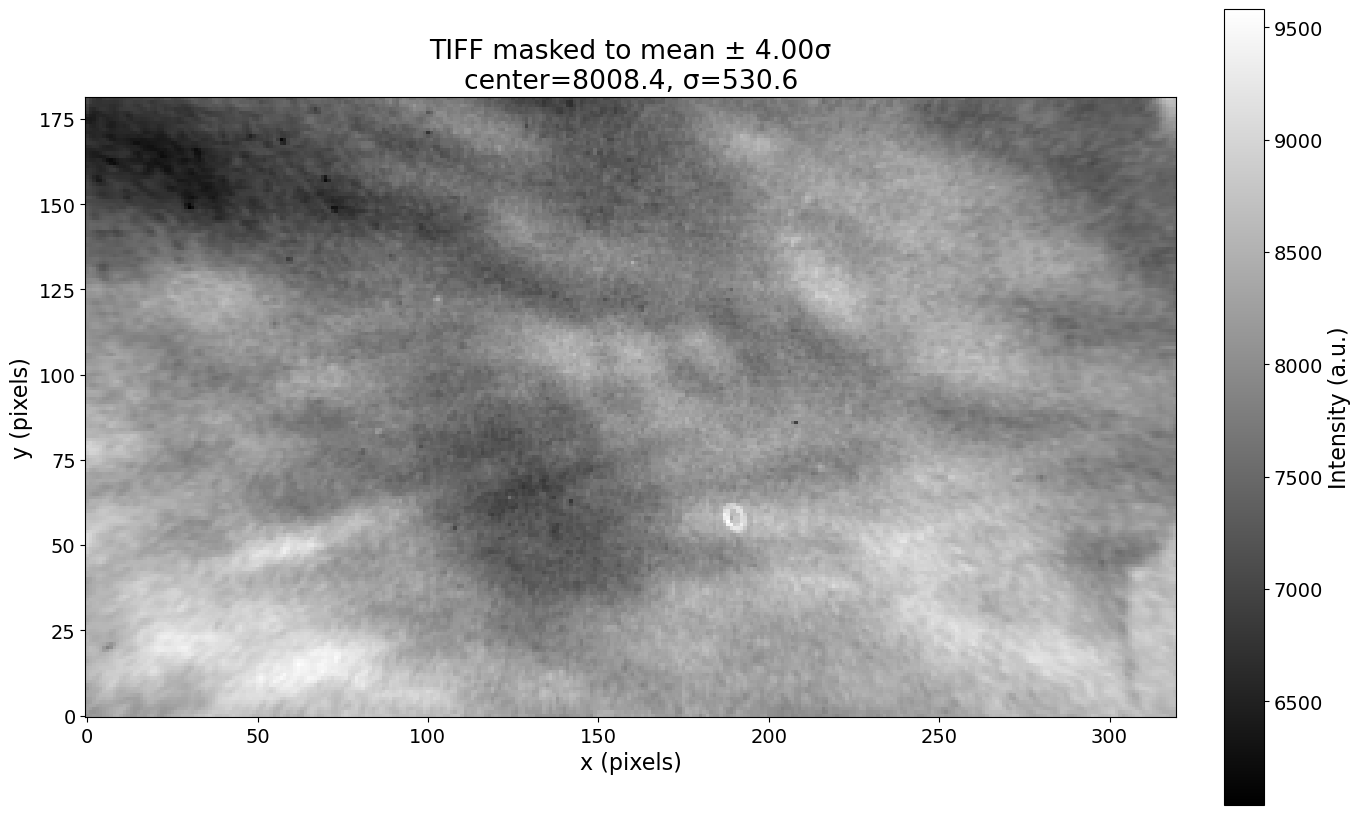

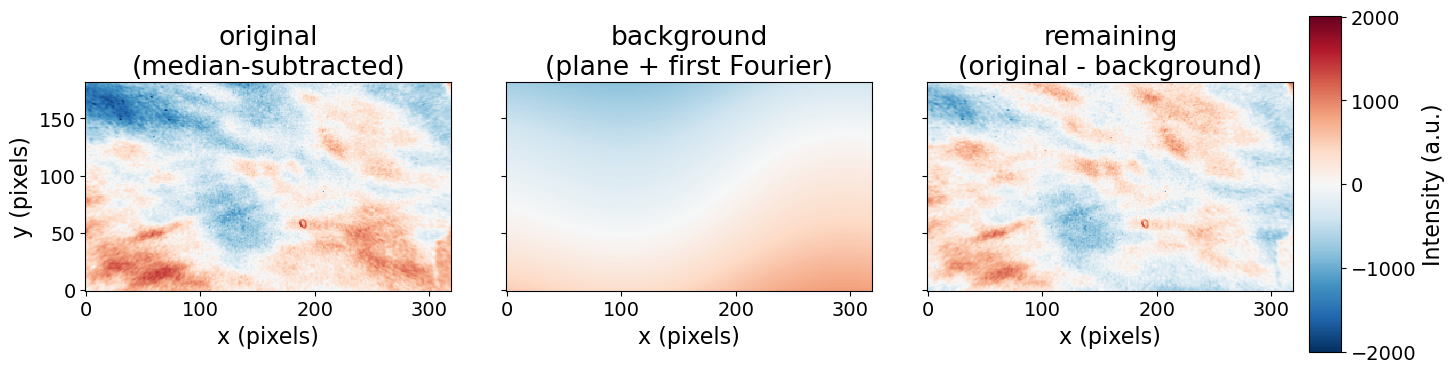

C:\Users\domin\juwavelet\juwavelet\transform.py:324: RuntimeWarning: divide by zero encountered in divide
  wys = periods[:, np.newaxis] / (aspect * np.sin(thetas[np.newaxis, :]))
C:\Users\domin\juwavelet\juwavelet\transform.py:367: RuntimeWarning: divide by zero encountered in divide
  "wavelength_y": periods[:, np.newaxis] / (aspect * np.sin(thetas[np.newaxis, :])),


------------
cluster= 0
amplitude= 0.3772795610101259 idx= (np.int64(12), np.int64(11), np.int64(64), np.int64(45))
selected elements: 175250
------------
cluster= 1
amplitude= 0.3716575596587417 idx= (np.int64(20), np.int64(7), np.int64(250), np.int64(111))
selected elements: 330642
------------
cluster= 2
amplitude= 0.3619750063419329 idx= (np.int64(29), np.int64(8), np.int64(64), np.int64(114))
selected elements: 1625761
------------
cluster= 3
amplitude= 0.35708439930612007 idx= (np.int64(16), np.int64(7), np.int64(128), np.int64(141))
selected elements: 125526
------------
cluster= 4
amplitude= 0.3383431831437283 idx= (np.int64(14), np.int64(9), np.int64(194), np.int64(52))
selected elements: 104804
------------
cluster= 5
amplitude= 0.3232140364961377 idx= (np.int64(13), np.int64(8), np.int64(102), np.int64(169))
selected elements: 23644
------------
cluster= 6
amplitude= 0.31249925106929616 idx= (np.int64(0), np.int64(0), np.int64(0), np.int64(169))
selected elements: 3072
-----

C:\Users\domin\juwavelet\juwavelet\utils.py:62: RuntimeWarning: divide by zero encountered in scalar divide
  hl = 1. / np.sin(theta[sel_t[j]])
100%|██████████████████████████████████████████████████████████████████████████████████| 13/13 [00:00<00:00, 70.56it/s]
C:\Users\domin\juwavelet\juwavelet\utils.py:89: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


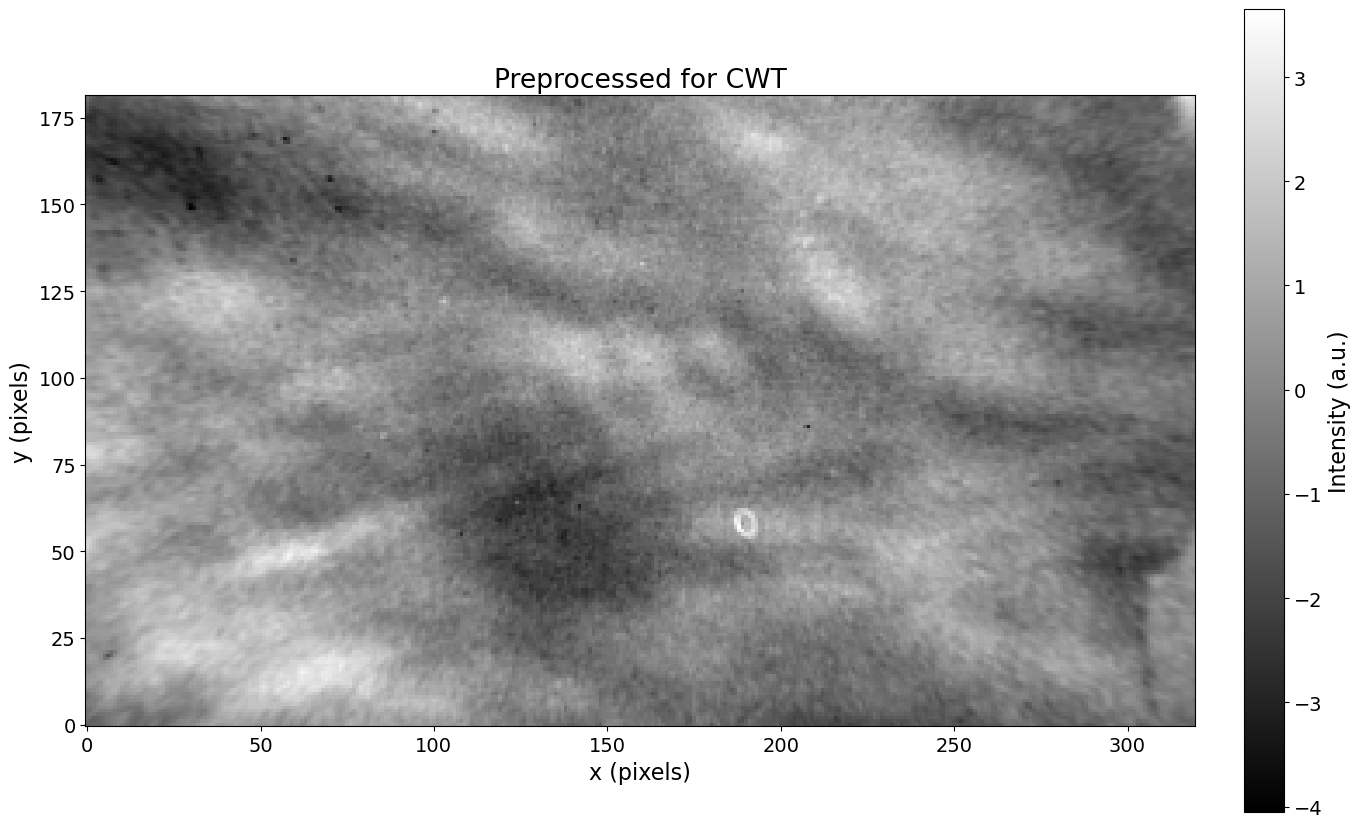

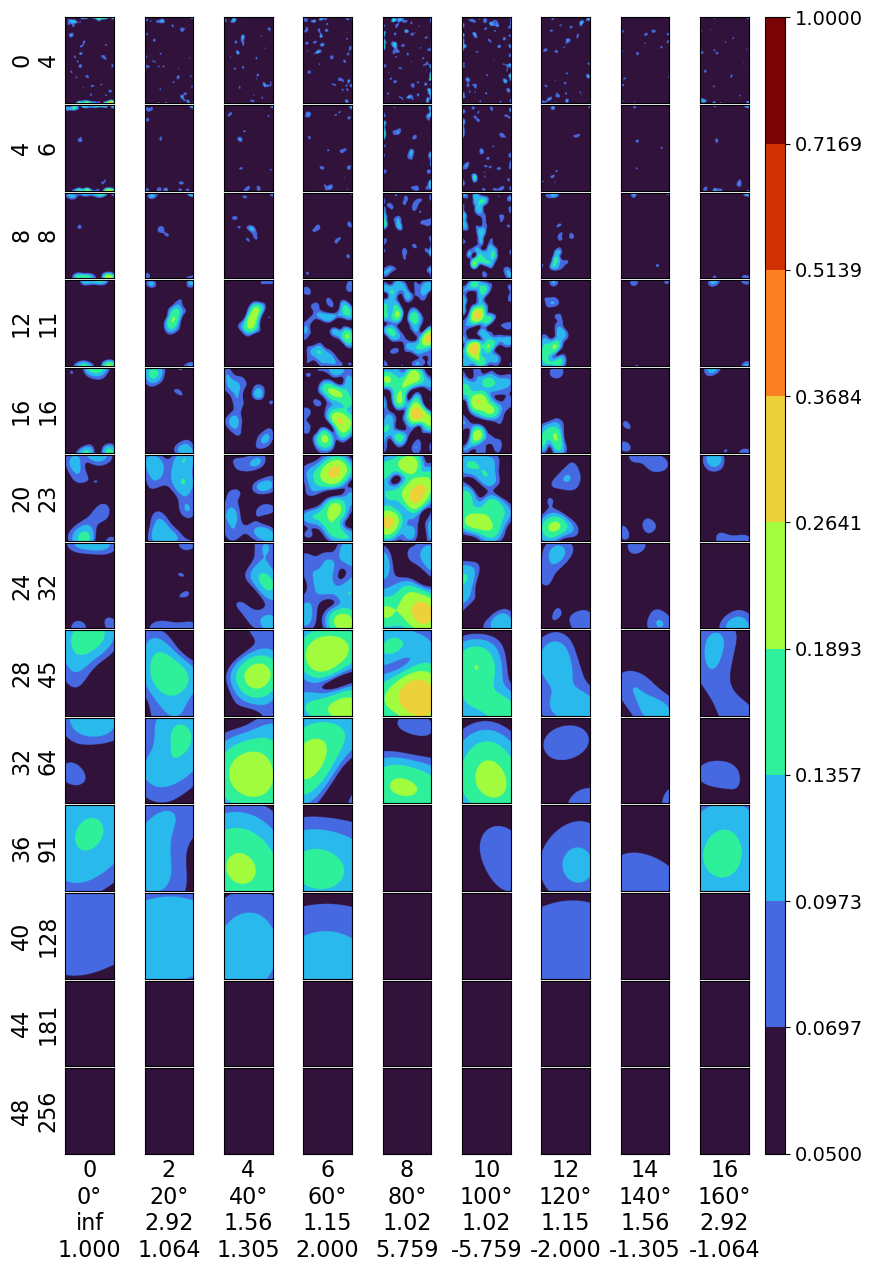

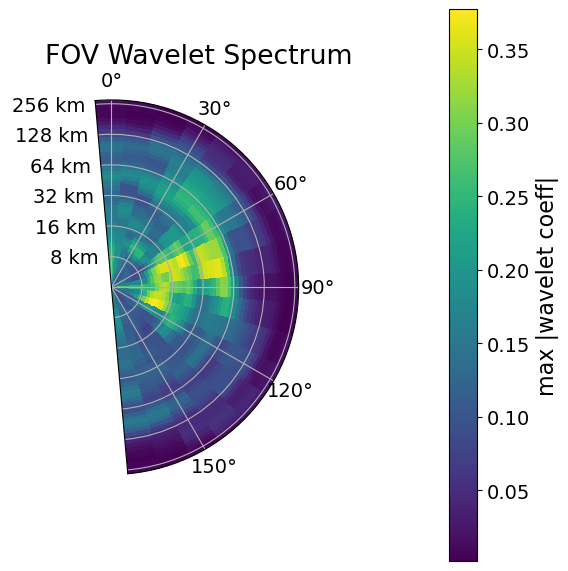

Cluster 0: amp=0.377, lamx=-33.08, lamy=12.04, lam=11.31
Cluster 1: amp=0.372, lamx=66.16, lamy=24.08, lam=22.63
Cluster 2: amp=0.362, lamx=284.20, lamy=50.11, lam=49.35
Cluster 3: amp=0.357, lamx=46.78, lamy=17.03, lam=16.00
Cluster 4: amp=0.338, lamx=219726090060038048.00, lamy=13.45, lam=13.45
Cluster 5: amp=0.323, lamx=71.05, lamy=12.53, lam=12.34


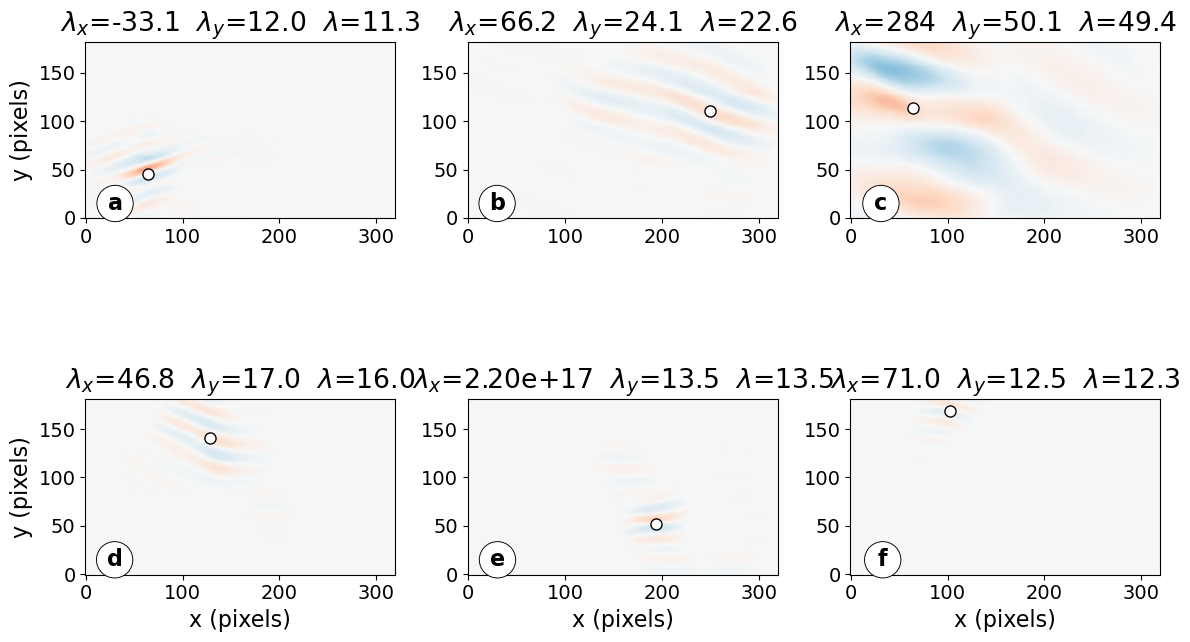

In [4]:
# example_decompose2d_from_tiff_rangefilter_top6.py
# Load a 16-bit TIFF, optionally mask values outside mean ± k·sigma for stats/preview,
# fill masked values for CWT, run juwavelet 2D CWT, and plot:
#   - masked/preview image
#   - original (median-sub), background (plane + first Fourier), remaining
#   - FOV wavelet spectrum
#   - 6 largest wave clusters

from __future__ import annotations
import string
from typing import Tuple, Optional, List

import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import tifffile as tiff

from juwavelet import transform, utils

# --------------------------
# User params
# --------------------------
TIFF_PATH = r"C:\Users\domin\juwavelet\examples\Waves For Anh\Sep14th527\BandOH_caun0121.tif"

# ROI (pixel slices). Set to None to use full image.
X_SLICE: Optional[slice] = None
Y_SLICE: Optional[slice] = slice(18, 200)

# Range filter: use mean ± k·sigma instead of fixed [6000, 10000]
APPLY_RANGE_FILTER = True
RANGE_SIGMA_FACTOR = 4   # k in mean ± k·sigma

# How to fill invalid pixels before CWT (to keep rectangular grid)
# choices: "median", "mean", "zero"
FILL_INVALID_FOR_CWT = "median"

# Preprocessing / background
REMOVE_TREND = True        # include 2D plane in "background"
STANDARDIZE = True         # z-score remaining field before CWT
GAUSS_BLUR_SIGMA = 0.0     # 0 disables, else e.g., 0.8

# Wavelet params
S0 = 4
DJ = 1/8
JS = 50
JT = 18
ASPECT = 1

# Pixel spacing (km/pixel) for CWT (wavelengths will be in km)
DX = 0.623
DY = 0.623

# --------------------------
# Plot style
# --------------------------
matplotlib.rcParams.update({
    "axes.labelsize": 16,
    "font.size": 16,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "legend.fontsize": 14,
    "figure.figsize": [2 * 6.94, 2 * 4.29],
})

# --------------------------
# Helpers
# --------------------------
def load_tiff_window(
    path: str,
    xsl: Optional[slice],
    ysl: Optional[slice],
) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    """Return (x_coords, y_coords, window) where window is float32 with shape (ny, nx)."""
    img = tiff.imread(path)
    if img.ndim == 3 and img.shape[-1] == 1:
        img = img[..., 0]
    if img.ndim != 2:
        raise ValueError(f"Expected single-frame 2D TIFF; got shape {img.shape}")

    Z = np.asarray(img, dtype=np.float32)

    if ysl is None:
        ysl = slice(None, None)
    if xsl is None:
        xsl = slice(None, None)
    win = Z[ysl, xsl]

    ny, nx = win.shape
    x = np.arange(nx, dtype=float)
    y = np.arange(ny, dtype=float)

    # Clean improbable NaNs/Infs
    med = float(np.median(win))
    win = np.nan_to_num(win, nan=med, posinf=med, neginf=med).astype(np.float32, copy=False)
    return x, y, win


def make_range_mask(Z: np.ndarray, lo: float, hi: float) -> np.ndarray:
    """True where value is inside [lo, hi]."""
    return (Z >= lo) & (Z <= hi)


def fit_plane(Z: np.ndarray) -> np.ndarray:
    """
    Fit a 2D plane ax + by + c to Z (least squares) and return the plane.
    """
    ny, nx = Z.shape
    yy, xx = np.mgrid[0:ny, 0:nx]
    G = np.stack([xx.ravel(), yy.ravel(), np.ones(nx * ny)], axis=1)
    coeff, *_ = np.linalg.lstsq(G, Z.ravel(), rcond=None)
    plane = (coeff[0] * xx + coeff[1] * yy + coeff[2])
    return plane


def detrend_plane(Z: np.ndarray) -> np.ndarray:
    """
    Backward-compatible helper: remove 2D plane from Z.
    (Not used in the new background decomp, but kept for reference.)
    """
    plane = fit_plane(Z)
    return Z - plane


def extract_first_fourier_bg(Z: np.ndarray) -> Tuple[np.ndarray, np.ndarray]:
    """
    From a 2D field Z, keep only the first Fourier components in x and y:

      - fundamental in x: kx = ±1, ky = 0
      - fundamental in y: ky = ±1, kx = 0

    Returns (background_from_fft, residual).
    """
    ny, nx = Z.shape
    F = np.fft.fft2(Z)
    F_bg = np.zeros_like(F, dtype=complex)

    # fundamental in x (along columns, ky = 0)
    if nx > 1:
        F_bg[0, 1] = F[0, 1]
        F_bg[0, -1] = F[0, -1]

    # fundamental in y (along rows, kx = 0)
    if ny > 1:
        F_bg[1, 0] = F[1, 0]
        F_bg[-1, 0] = F[-1, 0]

    bg = np.fft.ifft2(F_bg).real
    resid = Z - bg
    return bg, resid


def maybe_blur(Z: np.ndarray, sigma: float) -> np.ndarray:
    if sigma <= 0:
        return Z
    try:
        from scipy.ndimage import gaussian_filter
    except Exception:
        return Z
    return gaussian_filter(Z, sigma=float(sigma))


def quicklook_pcolor(x1d: np.ndarray, y1d: np.ndarray, Z: np.ndarray, title: str, cmap="gray") -> None:
    fig, ax = plt.subplots()
    im = ax.pcolormesh(x1d, y1d, Z, shading="auto", cmap=cmap)
    cb = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cb.set_label("Intensity (a.u.)")
    ax.set_xlabel("x (pixels)")
    ax.set_ylabel("y (pixels)")
    ax.set_title(title)
    ax.set_aspect("equal", adjustable="box")
    plt.tight_layout()


def quicklook_background_decomp(
    x1d: np.ndarray,
    y1d: np.ndarray,
    original: np.ndarray,
    background: np.ndarray,
    remaining: np.ndarray,
) -> None:
    """
    Show three panels:
      (a) original field (median-subtracted)
      (b) background = 2D plane + first Fourier component in x and y (median-subtracted)
      (c) remaining = original - background  (NO extra median subtraction)
    """
    med = np.nanmedian(original)

    # Median-center original & background
    orig_c = original - med
    bg_c = background - med

    # Remaining is exactly original - background
    rem_c = original - background

    stacked = np.concatenate([orig_c.ravel(), bg_c.ravel(), rem_c.ravel()])
    vmax = float(np.nanmax(np.abs(stacked)))
    if vmax == 0 or not np.isfinite(vmax):
        vmax = 1.0
    vmin = -vmax

    fig, axs = plt.subplots(1, 3, figsize=(16, 4.8), sharey=True)

    im0 = axs[0].pcolormesh(
        x1d, y1d, orig_c,
        shading="auto", cmap="RdBu_r", vmin=vmin, vmax=vmax
    )
    axs[0].set_title("original\n(median-subtracted)")

    axs[1].pcolormesh(
        x1d, y1d, bg_c,
        shading="auto", cmap="RdBu_r", vmin=vmin, vmax=vmax
    )
    axs[1].set_title("background\n(plane + first Fourier)")

    axs[2].pcolormesh(
        x1d, y1d, rem_c,
        shading="auto", cmap="RdBu_r", vmin=vmin, vmax=vmax
    )
    axs[2].set_title("remaining\n(original - background)")

    for ax in axs:
        ax.set_xlabel("x (pixels)")
        ax.set_aspect("equal", adjustable="box")
    axs[0].set_ylabel("y (pixels)")

    fig.subplots_adjust(right=0.88, wspace=0.15)
    cax = fig.add_axes([0.89, 0.15, 0.02, 0.7])
    cbar = fig.colorbar(im0, cax=cax)
    cbar.set_label("Intensity (a.u.)")

    plt.show()


def fill_invalid(Z: np.ndarray, valid_mask: np.ndarray, how: str) -> np.ndarray:
    """Fill invalid pixels to keep rectangular grid before CWT."""
    out = Z.copy()
    if valid_mask is None:
        return out
    inv = ~valid_mask
    if not np.any(inv):
        return out
    if how == "median":
        val = float(np.median(out[~inv])) if np.any(~inv) else float(np.median(out))
    elif how == "mean":
        val = float(np.mean(out[~inv])) if np.any(~inv) else float(np.mean(out))
    elif how == "zero":
        val = 0.0
    else:
        raise ValueError("FILL_INVALID_FOR_CWT must be 'median', 'mean', or 'zero'")
    out[inv] = val
    return out


def _fmt(v: float) -> str:
    if not np.isfinite(v):
        return "∞"
    v = float(v)
    if abs(v) >= 1000 or abs(v) < 0.1:
        return f"{v:.2e}"
    elif abs(v) >= 100:
        return f"{v:.0f}"
    else:
        return f"{v:.1f}"


def plot_fov_wavelet_spectrum(cwt, stat: str = "mean"):
    """
    Make a 0–180° half-circle polar plot of wave energy vs orientation and wavelength.
    Radial axis uses the juwavelet wavelengths (km), log-scaled.
    Major tick labels: 8, 16, 32, 64, 128, ...
    """

    import matplotlib.pyplot as plt

    # 1. Amplitude statistic
    amp = np.abs(cwt["decomposition"])  # (ns, nt, nx, ny)

    if stat == "mean":
        spec = np.nanmean(amp, axis=(2, 3))  # (ns, nt)
    elif stat == "max":
        spec = np.nanmax(amp, axis=(2, 3))   # (ns, nt)
    else:
        raise ValueError("stat must be 'mean' or 'max'")

    # 2. Wavelengths and angles
    if "wavelength" in cwt:
        lam = np.asarray(cwt["wavelength"])
    else:
        lam = np.asarray(cwt["period"])

    lam1d = lam[:, 0] if lam.ndim == 2 else lam

    theta_arr = np.asarray(cwt["theta"])
    theta1d = theta_arr[0, :] if theta_arr.ndim == 2 else theta_arr

    # 3. Edges for pcolormesh
    def edges(x):
        mid = 0.5 * (x[:-1] + x[1:])
        first = x[0] - (mid[0] - x[0])
        last  = x[-1] + (x[-1] - mid[-1])
        return np.concatenate([[first], mid, [last]])

    lam_edges = edges(lam1d)
    th_edges = edges(theta1d)

    TH, R = np.meshgrid(th_edges, lam_edges)

    # 4. Plot
    fig, ax = plt.subplots(
        figsize=(6, 6),
        subplot_kw={"projection": "polar"}
    )

    # Half circle: approximately 0–180°
    ax.set_thetamin(-5)
    ax.set_thetamax(175)

    ax.set_theta_zero_location("N")
    ax.set_theta_direction(-1)

    ax.set_yscale("log")
    ax.set_ylim(lam1d.min(), lam1d.max())

    major_ticks = []
    for v in [4, 8, 16, 32, 64, 128, 256, 512]:
        if lam1d.min() <= v <= lam1d.max():
            major_ticks.append(v)
    ax.set_yticks(major_ticks)
    ax.set_yticklabels([f"{int(v)} km" for v in major_ticks])

    im = ax.pcolormesh(TH, R, spec, shading="auto", cmap="viridis")

    ax.set_title("FOV Wavelet Spectrum", pad=24)

    cbar = fig.colorbar(im, pad=0.12)
    cbar.set_label("mean |wavelet coeff|" if stat == "mean" else "max |wavelet coeff|")

    plt.tight_layout()
    plt.show()


# --------------------------
# Pipeline
# --------------------------
def run_pipeline():
    # 1) Load TIFF window
    x1d, y1d, raw = load_tiff_window(TIFF_PATH, X_SLICE, Y_SLICE)

    # 2) Compute mean/std and dynamic range: mean ± k·sigma
    sample = raw.ravel().astype(float)
    center = float(np.mean(sample))
    sigma = float(np.std(sample))
    k = RANGE_SIGMA_FACTOR
    lo = center - k * sigma
    hi = center + k * sigma

    print(f"Center (mean): {center:.2f}")
    print(f"Sigma (std):   {sigma:.2f}")
    print(f"Dynamic range: [{lo:.2f}, {hi:.2f}] = mean ± {k:.2f}·sigma")

    # 3) Range filter for preview
    mask = None
    if APPLY_RANGE_FILTER:
        mask = make_range_mask(raw, lo, hi)
        preview = raw.copy().astype(float)
        preview[~mask] = np.nan

        vals = preview[np.isfinite(preview)]
        if vals.size > 0:
            print(f"In-range count: {vals.size}")
            print(f"In-range min/max: {np.nanmin(vals):.2f} / {np.nanmax(vals):.2f}")
            print(f"In-range mean/std: {np.nanmean(vals):.2f} / {np.nanstd(vals):.2f}")
            p5, p50, p95 = np.nanpercentile(vals, [5, 50, 95])
            print(f"In-range percentiles 5/50/95: {p5:.2f} / {p50:.2f} / {p95:.2f}")
        else:
            print("Warning: no pixels within mean ± k·sigma")

        disp = np.clip(preview, lo, hi)
        quicklook_pcolor(
            x1d,
            y1d,
            disp,
            f"TIFF masked to mean ± {k:.2f}σ\ncenter={center:.1f}, σ={sigma:.1f}",
        )
    else:
        disp = np.clip(raw, lo, hi)
        quicklook_pcolor(
            x1d,
            y1d,
            disp,
            f"TIFF raw, display mean ± {k:.2f}σ\ncenter={center:.1f}, σ={sigma:.1f}",
        )

    # 4) Prepare data for CWT: fill removed pixels to keep rectangular grid
    filled = fill_invalid(raw, mask, FILL_INVALID_FOR_CWT) if APPLY_RANGE_FILTER else raw

    # 5) Background separation: plane + first Fourier
    proc0 = filled.copy()
    if REMOVE_TREND:
        plane = fit_plane(proc0)
        detrended = proc0 - plane
    else:
        plane = np.zeros_like(proc0)
        detrended = proc0

    fourier_bg, resid_after_fft = extract_first_fourier_bg(detrended)
    background = plane + fourier_bg
    remaining = proc0 - background

    # Plot original / background / remaining
    quicklook_background_decomp(x1d, y1d, proc0, background, remaining)

    # 6) Continue preprocessing on the remaining field
    proc = remaining.copy()
    if STANDARDIZE:
        m = np.median(proc)
        s = np.std(proc)
        proc = (proc - m) / s if s > 0 else (proc - m)
    proc = maybe_blur(proc, GAUSS_BLUR_SIGMA)

    quicklook_pcolor(x1d, y1d, proc, "Preprocessed for CWT")

    # juwavelet expects (nx, ny); image is (ny, nx)
    wave_xy = proc.T

    cwt = transform.decompose2d(
        wave_xy, dx=DX, dy=DY, s0=S0, dj=DJ, js=JS, jt=JT, aspect=ASPECT
    )

    # 7) Identify clusters
    amps, idxs, iwave = utils.identify_cluster2d(cwt, min_amp=0.25, thr=0.15)

    decomposition, period, theta = [cwt[k] for k in ("decomposition", "period", "theta")]
    orig = decomposition.copy()

    # 8) Overview CWT plot
    cmap = matplotlib.cm.turbo
    norm = matplotlib.colors.BoundaryNorm(
        np.exp(np.linspace(np.log(0.05), np.log(1.0), 10)), cmap.N
    )
    fig1, _ = utils.plot_decomposition2d(cwt, redux_s=4, redux_t=2, cmap=cmap, norm=norm)

    # 9) FOV wavelet spectrum
    plot_fov_wavelet_spectrum(cwt, stat="max")

    # 10) Component panels: 6 largest clusters
    fig2, axs = plt.subplots(2, 3, figsize=(12, 8))
    axes_flat = axs.flatten()

    opts_img = {"cmap": "RdBu_r", "vmin": -2.5, "vmax": 2.5, "rasterized": True}

    n_clusters = len(amps) if amps is not None else 0

    if n_clusters == 0:
        for ax in axes_flat:
            ax.set_title("no clusters found")
            ax.axis("off")
    else:
        order = np.argsort(amps)[::-1]
        n_show = min(6, n_clusters)
        biggest = order[:n_show]

        for ax, kcl in zip(axes_flat, biggest):
            # Reconstruct this cluster only
            decomposition[:] = orig
            decomposition[iwave != kcl] = 0
            rec = transform.reconstruct2d(cwt)  # (nx, ny)

            rec_centered = rec.T - np.median(rec)

            udx = idxs[kcl]            # (s_idx, t_idx, ...)
            s_idx = int(udx[0])
            t_idx = int(udx[1])

            lamx = cwt["wavelength_x"][s_idx, t_idx]
            lamy = cwt["wavelength_y"][s_idx, t_idx]

            inv2 = 0.0
            if np.isfinite(lamx) and lamx != 0:
                inv2 += (1.0 / lamx) ** 2
            if np.isfinite(lamy) and lamy != 0:
                inv2 += (1.0 / lamy) ** 2
            lam = np.inf if inv2 == 0 else 1.0 / np.sqrt(inv2)

            ax.set_title(
                rf"$\lambda_x$={_fmt(lamx)}  "
                rf"$\lambda_y$={_fmt(lamy)}  "
                rf"$\lambda$={_fmt(lam)}"
            )
            ax.pcolormesh(x1d, y1d, rec_centered, **opts_img)

            # Mark peak location
            decomposition[:] = np.abs(decomposition)
            max_idx = np.unravel_index(
                decomposition[s_idx, t_idx].argmax(), decomposition[0, 0].shape
            )
            ax.plot(
                x1d[max_idx[0]],
                y1d[max_idx[1]],
                "o", color="w", mec="k", ms=8,
            )

            ax.set_aspect("equal", adjustable="box")

            print(
                f"Cluster {kcl}: amp={amps[kcl]:.3f}, "
                f"lamx={lamx:.2f}, lamy={lamy:.2f}, "
                f"lam={'inf' if not np.isfinite(lam) else f'{lam:.2f}'}"
            )

        # If fewer than 6 clusters, hide the remaining axes
        for ax in axes_flat[n_show:]:
            ax.set_title("no cluster")
            ax.axis("off")

    # Axis labels (pixels)
    for ax in axs[1, :]:
        ax.set_xlabel("x (pixels)")
    for ax in axs[:, 0]:
        ax.set_ylabel("y (pixels)")

    # Letter tags (a–f)
    letterbox = {"boxstyle": "circle", "lw": 0.67,
                 "facecolor": "white", "edgecolor": "black"}
    for ax, letter in zip(axes_flat, string.ascii_lowercase):
        ax.text(
            0.12,
            0.15,
            letter,
            transform=ax.transAxes,
            bbox=letterbox,
            va="top",
            ha="right",
            weight="bold",
        )

    fig2.tight_layout()

    # Show both the decomposition overview and cluster figure
    plt.show(fig1)
    plt.show(fig2)


# --------------------------
# Run
# --------------------------
if __name__ == "__main__":
    run_pipeline()


## 9 Subplots

Center (mean): 8008.42
Sigma (std):   530.62
Dynamic range: [5885.95, 10130.89] = mean ± 4.00·sigma
In-range count: 58240
In-range min/max: 6039.00 / 9581.00
In-range mean/std: 8008.42 / 530.62
In-range percentiles 5/50/95: 7113.00 / 8046.00 / 8853.00


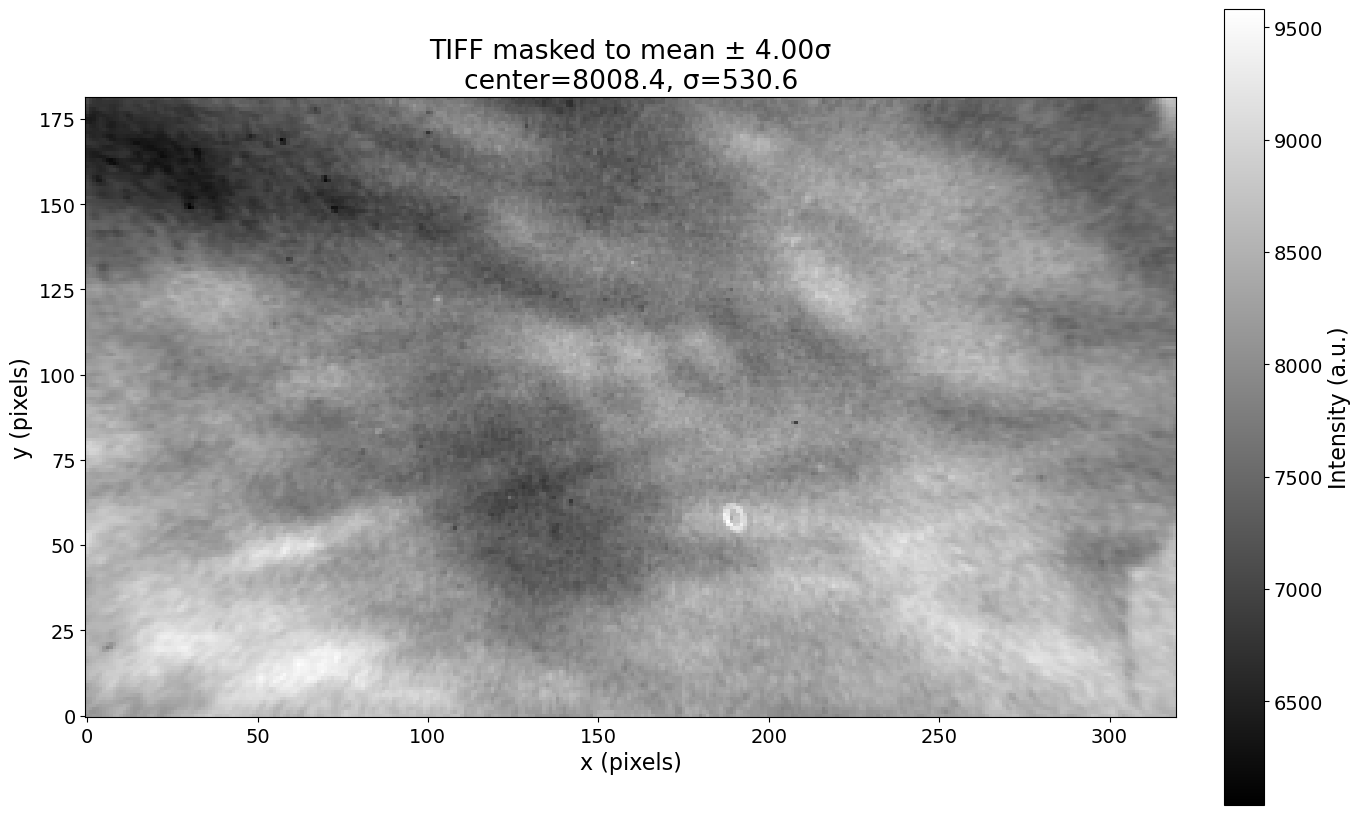

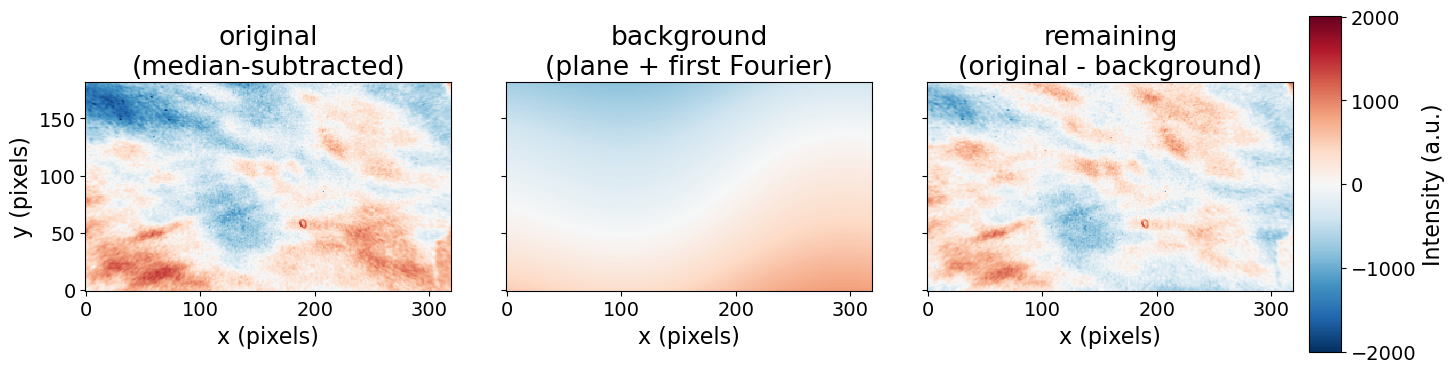

C:\Users\domin\juwavelet\juwavelet\transform.py:324: RuntimeWarning: divide by zero encountered in divide
  wys = periods[:, np.newaxis] / (aspect * np.sin(thetas[np.newaxis, :]))
C:\Users\domin\juwavelet\juwavelet\transform.py:367: RuntimeWarning: divide by zero encountered in divide
  "wavelength_y": periods[:, np.newaxis] / (aspect * np.sin(thetas[np.newaxis, :])),


------------
cluster= 0
amplitude= 0.3772795610101259 idx= (np.int64(12), np.int64(11), np.int64(64), np.int64(45))
selected elements: 54171
------------
cluster= 1
amplitude= 0.3716575596587417 idx= (np.int64(20), np.int64(7), np.int64(250), np.int64(111))
selected elements: 95746
------------
cluster= 2
amplitude= 0.3619750063419329 idx= (np.int64(29), np.int64(8), np.int64(64), np.int64(114))
selected elements: 579297
------------
cluster= 3
amplitude= 0.35708439930612007 idx= (np.int64(16), np.int64(7), np.int64(128), np.int64(141))
selected elements: 61964
------------
cluster= 4
amplitude= 0.3383431831437283 idx= (np.int64(14), np.int64(9), np.int64(194), np.int64(52))
selected elements: 37929
------------
cluster= 5
amplitude= 0.3359491174273 idx= (np.int64(13), np.int64(7), np.int64(108), np.int64(167))
selected elements: 12057
------------
cluster= 6
amplitude= 0.31249925106929616 idx= (np.int64(0), np.int64(0), np.int64(0), np.int64(169))
selected elements: 1084
------------


C:\Users\domin\juwavelet\juwavelet\utils.py:62: RuntimeWarning: divide by zero encountered in scalar divide
  hl = 1. / np.sin(theta[sel_t[j]])
100%|██████████████████████████████████████████████████████████████████████████████████| 13/13 [00:00<00:00, 70.31it/s]
C:\Users\domin\juwavelet\juwavelet\utils.py:89: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


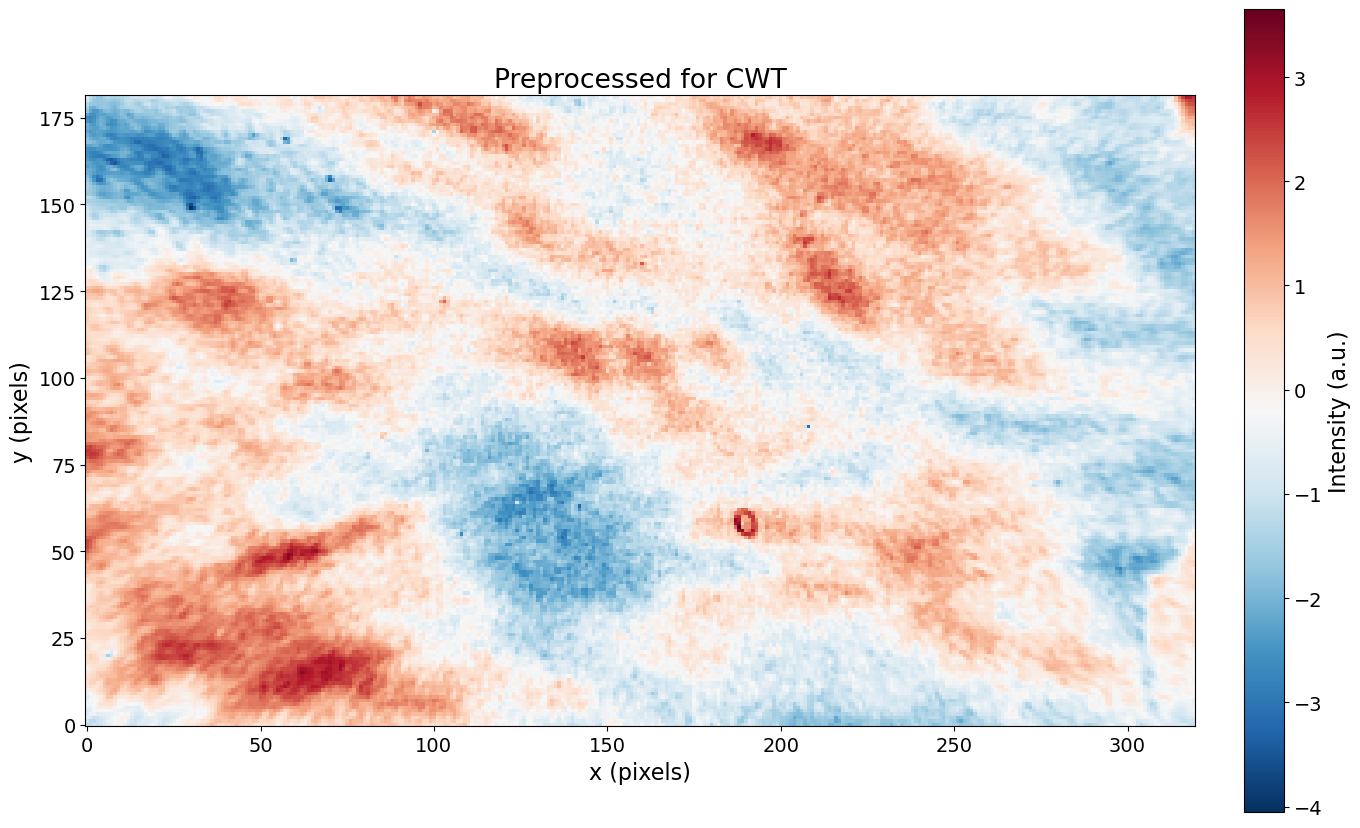

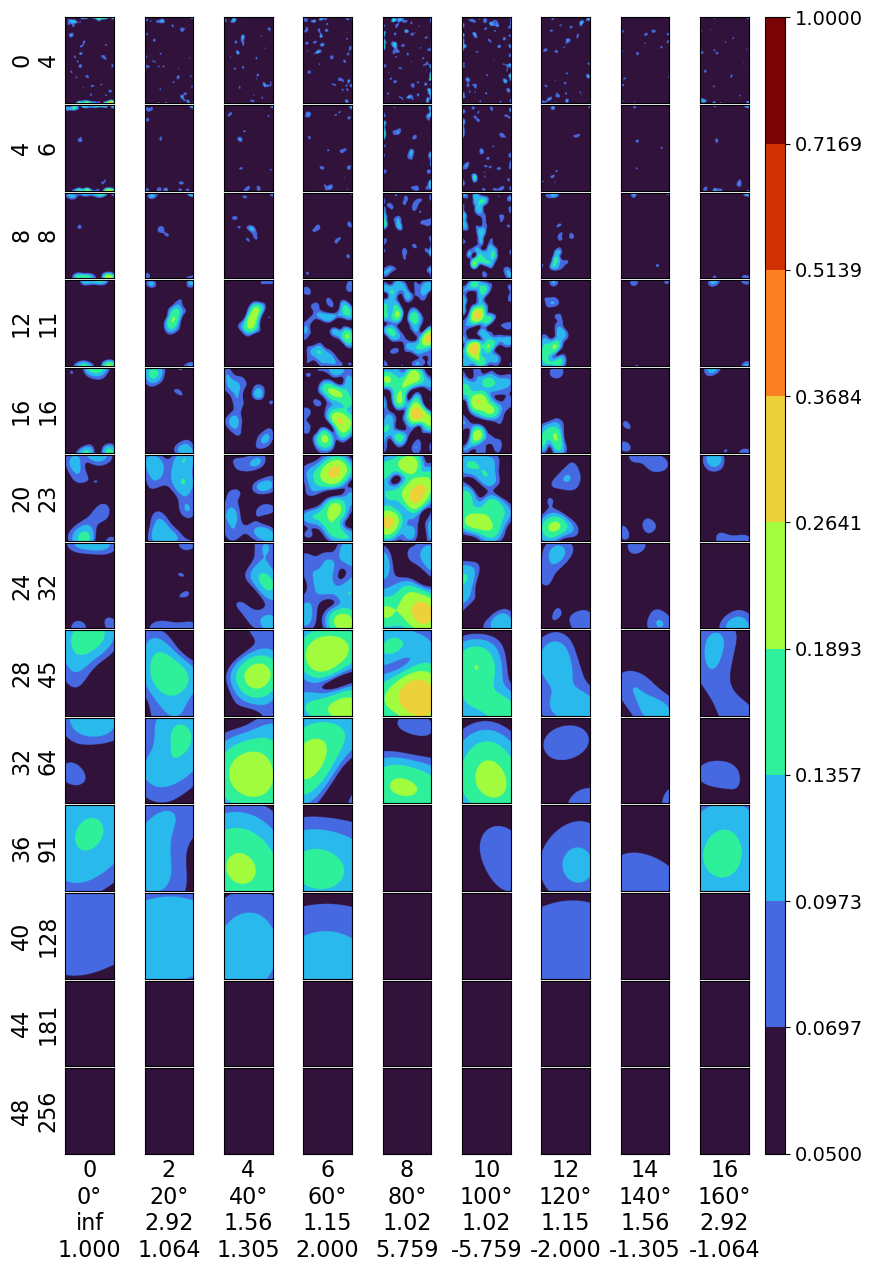

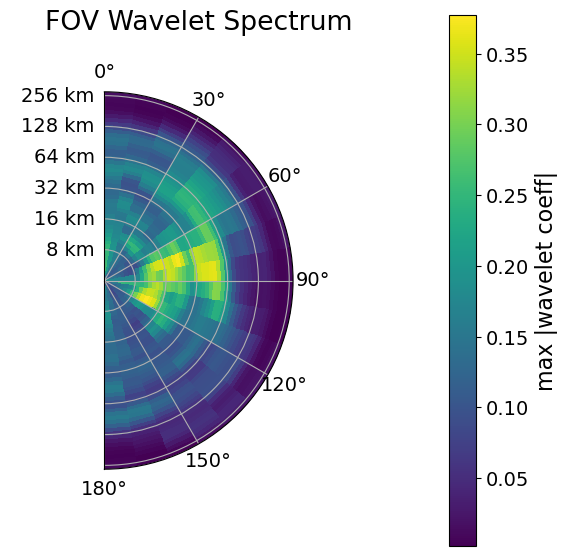

Cluster 0: amp=0.377, lamx=-33.08, lamy=12.04, lam=11.31
Cluster 1: amp=0.372, lamx=66.16, lamy=24.08, lam=22.63
Cluster 2: amp=0.362, lamx=284.20, lamy=50.11, lam=49.35
Cluster 3: amp=0.357, lamx=46.78, lamy=17.03, lam=16.00
Cluster 4: amp=0.338, lamx=219726090060038048.00, lamy=13.45, lam=13.45
Cluster 5: amp=0.336, lamx=36.07, lamy=13.13, lam=12.34
Cluster 6: amp=0.312, lamx=4.00, lamy=inf, lam=4.00
Cluster 7: amp=0.304, lamx=130.31, lamy=22.98, lam=22.63
Cluster 8: amp=0.303, lamx=109.57, lamy=19.32, lam=19.03


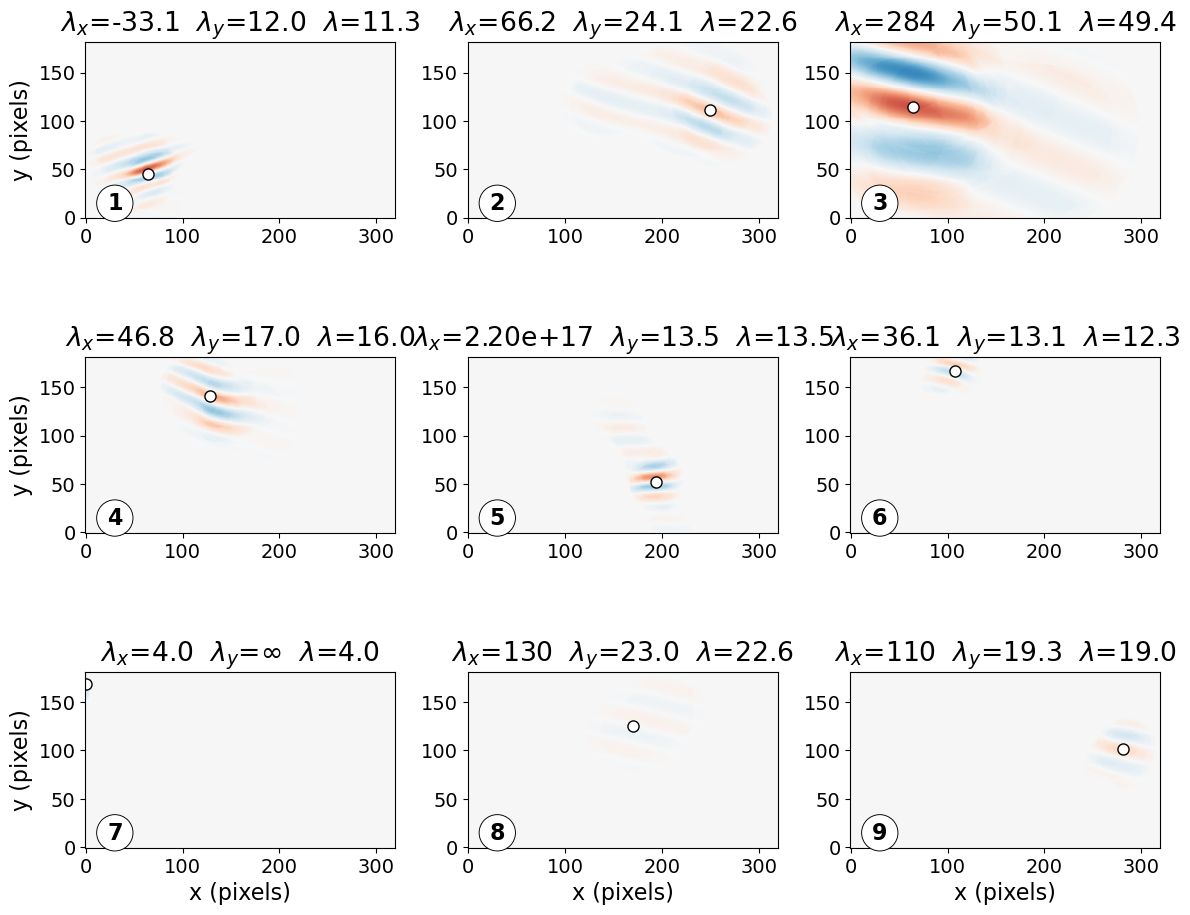

In [3]:
# Load a 16-bit TIFF, optionally mask values outside mean ± k·sigma for stats/preview,
# fill masked values for CWT, run juwavelet 2D CWT, and plot:
#   - masked/preview image
#   - original (median-sub), background (plane + first Fourier), remaining
#   - preprocessed-for-CWT (same color scale as above)
#   - FOV wavelet spectrum
#   - 9 largest wave clusters

from __future__ import annotations
from typing import Tuple, Optional

import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import tifffile as tiff

from juwavelet import transform, utils, plot_utils

# --------------------------
# User params
# --------------------------
TIFF_PATH = r"C:\Users\domin\juwavelet\examples\Waves For Anh\Sep14th527\BandOH_caun0121.tif"

# ROI (pixel slices). Set to None to use full image.
X_SLICE: Optional[slice] = None
Y_SLICE: Optional[slice] = slice(18, 200)

# Range filter: use mean ± k·sigma instead of fixed [6000, 10000]
APPLY_RANGE_FILTER = True
RANGE_SIGMA_FACTOR = 4   # k in mean ± k·sigma

# How to fill invalid pixels before CWT (to keep rectangular grid)
# choices: "median", "mean", "zero"
FILL_INVALID_FOR_CWT = "median"

# Preprocessing / background
REMOVE_TREND = True        # include 2D plane in "background"
STANDARDIZE = True         # z-score remaining field before CWT
GAUSS_BLUR_SIGMA = 0.0     # 0 disables, else e.g., 0.8

# Wavelet params
S0 = 4
DJ = 1/8
JS = 50
JT = 18
ASPECT = 1

# Pixel spacing (km/pixel) for CWT (wavelengths will be in km)
DX = 0.623
DY = 0.623

# --------------------------
# Plot style
# --------------------------
matplotlib.rcParams.update({
    "axes.labelsize": 16,
    "font.size": 16,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "legend.fontsize": 14,
    "figure.figsize": [2 * 6.94, 2 * 4.29],
})

# --------------------------
# Helpers
# --------------------------
def load_tiff_window(
    path: str,
    xsl: Optional[slice],
    ysl: Optional[slice],
) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    """Return (x_coords, y_coords, window) where window is float32 with shape (ny, nx)."""
    img = tiff.imread(path)
    if img.ndim == 3 and img.shape[-1] == 1:
        img = img[..., 0]
    if img.ndim != 2:
        raise ValueError(f"Expected single-frame 2D TIFF; got shape {img.shape}")

    Z = np.asarray(img, dtype=np.float32)

    if ysl is None:
        ysl = slice(None, None)
    if xsl is None:
        xsl = slice(None, None)
    win = Z[ysl, xsl]

    ny, nx = win.shape
    x = np.arange(nx, dtype=float)
    y = np.arange(ny, dtype=float)

    # Clean improbable NaNs/Infs
    med = float(np.median(win))
    win = np.nan_to_num(win, nan=med, posinf=med, neginf=med).astype(np.float32, copy=False)
    return x, y, win


def make_range_mask(Z: np.ndarray, lo: float, hi: float) -> np.ndarray:
    """True where value is inside [lo, hi]."""
    return (Z >= lo) & (Z <= hi)


def fit_plane(Z: np.ndarray) -> np.ndarray:
    """
    Fit a 2D plane ax + by + c to Z (least squares) and return the plane.
    """
    ny, nx = Z.shape
    yy, xx = np.mgrid[0:ny, 0:nx]
    G = np.stack([xx.ravel(), yy.ravel(), np.ones(nx * ny)], axis=1)
    coeff, *_ = np.linalg.lstsq(G, Z.ravel(), rcond=None)
    plane = (coeff[0] * xx + coeff[1] * yy + coeff[2])
    return plane


def extract_first_fourier_bg(Z: np.ndarray) -> Tuple[np.ndarray, np.ndarray]:
    """
    From a 2D field Z, keep only the first Fourier components in x and y:

      - fundamental in x: kx = ±1, ky = 0
      - fundamental in y: ky = ±1, kx = 0

    Returns (background_from_fft, residual).
    """
    ny, nx = Z.shape
    F = np.fft.fft2(Z)
    F_bg = np.zeros_like(F, dtype=complex)

    # fundamental in x (along columns, ky = 0)
    if nx > 1:
        F_bg[0, 1] = F[0, 1]
        F_bg[0, -1] = F[0, -1]

    # fundamental in y (along rows, kx = 0)
    if ny > 1:
        F_bg[1, 0] = F[1, 0]
        F_bg[-1, 0] = F[-1, 0]

    bg = np.fft.ifft2(F_bg).real
    resid = Z - bg
    return bg, resid


def maybe_blur(Z: np.ndarray, sigma: float) -> np.ndarray:
    if sigma <= 0:
        return Z
    try:
        from scipy.ndimage import gaussian_filter
    except Exception:
        return Z
    return gaussian_filter(Z, sigma=float(sigma))


def quicklook_pcolor(
    x1d: np.ndarray,
    y1d: np.ndarray,
    Z: np.ndarray,
    title: str,
    cmap="gray",
    vmin: float = None,
    vmax: float = None,
) -> None:
    fig, ax = plt.subplots()
    im = ax.pcolormesh(x1d, y1d, Z, shading="auto", cmap=cmap, vmin=vmin, vmax=vmax)
    cb = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cb.set_label("Intensity (a.u.)")
    ax.set_xlabel("x (pixels)")
    ax.set_ylabel("y (pixels)")
    ax.set_title(title)
    ax.set_aspect("equal", adjustable="box")
    plt.tight_layout()


def fill_invalid(Z: np.ndarray, valid_mask: np.ndarray, how: str) -> np.ndarray:
    """Fill invalid pixels to keep rectangular grid before CWT."""
    out = Z.copy()
    if valid_mask is None:
        return out
    inv = ~valid_mask
    if not np.any(inv):
        return out
    if how == "median":
        val = float(np.median(out[~inv])) if np.any(~inv) else float(np.median(out))
    elif how == "mean":
        val = float(np.mean(out[~inv])) if np.any(~inv) else float(np.mean(out))
    elif how == "zero":
        val = 0.0
    else:
        raise ValueError("FILL_INVALID_FOR_CWT must be 'median', 'mean', or 'zero'")
    out[inv] = val
    return out


def _fmt(v: float) -> str:
    if not np.isfinite(v):
        return "∞"
    v = float(v)
    if abs(v) >= 1000 or abs(v) < 0.1:
        return f"{v:.2e}"
    elif abs(v) >= 100:
        return f"{v:.0f}"
    else:
        return f"{v:.1f}"

# --------------------------
# Pipeline
# --------------------------
def run_pipeline():
    # 1) Load TIFF window
    x1d, y1d, raw = load_tiff_window(TIFF_PATH, X_SLICE, Y_SLICE)

    # 2) Compute mean/std and dynamic range: mean ± k·sigma
    sample = raw.ravel().astype(float)
    center = float(np.mean(sample))
    sigma = float(np.std(sample))
    k = RANGE_SIGMA_FACTOR
    lo = center - k * sigma
    hi = center + k * sigma

    print(f"Center (mean): {center:.2f}")
    print(f"Sigma (std):   {sigma:.2f}")
    print(f"Dynamic range: [{lo:.2f}, {hi:.2f}] = mean ± {k:.2f}·sigma")

    # 3) Range filter for preview
    mask = None
    if APPLY_RANGE_FILTER:
        mask = make_range_mask(raw, lo, hi)
        preview = raw.copy().astype(float)
        preview[~mask] = np.nan

        vals = preview[np.isfinite(preview)]
        if vals.size > 0:
            print(f"In-range count: {vals.size}")
            print(f"In-range min/max: {np.nanmin(vals):.2f} / {np.nanmax(vals):.2f}")
            print(f"In-range mean/std: {np.nanmean(vals):.2f} / {np.nanstd(vals):.2f}")
            p5, p50, p95 = np.nanpercentile(vals, [5, 50, 95])
            print(f"In-range percentiles 5/50/95: {p5:.2f} / {p50:.2f} / {p95:.2f}")
        else:
            print("Warning: no pixels within mean ± k·sigma")

        disp = np.clip(preview, lo, hi)
        quicklook_pcolor(
            x1d,
            y1d,
            disp,
            f"TIFF masked to mean ± {k:.2f}σ\ncenter={center:.1f}, σ={sigma:.1f}",
        )
    else:
        disp = np.clip(raw, lo, hi)
        quicklook_pcolor(
            x1d,
            y1d,
            disp,
            f"TIFF raw, display mean ± {k:.2f}σ\ncenter={center:.1f}, σ={sigma:.1f}",
        )

    # 4) Prepare data for CWT: fill removed pixels to keep rectangular grid
    filled = fill_invalid(raw, mask, FILL_INVALID_FOR_CWT) if APPLY_RANGE_FILTER else raw

    # 5) Background separation: plane + first Fourier
    proc0 = filled.copy()
    if REMOVE_TREND:
        plane = fit_plane(proc0)
        detrended = proc0 - plane
    else:
        plane = np.zeros_like(proc0)
        detrended = proc0

    fourier_bg, _ = extract_first_fourier_bg(detrended)
    background = plane + fourier_bg
    remaining = proc0 - background

    # Compute global vmin/vmax for background + remaining + original
    med = np.nanmedian(proc0)
    orig_c = proc0 - med
    bg_c = background - med
    rem_c = remaining  # already original - background
    stacked = np.concatenate([orig_c.ravel(), bg_c.ravel(), rem_c.ravel()])
    vmax = float(np.nanmax(np.abs(stacked)))
    if vmax == 0 or not np.isfinite(vmax):
        vmax = 1.0
    vmin = -vmax

    # Plot original / background / remaining with shared color scale
    plot_utils.quicklook_background_decomp(x1d, y1d, proc0, background, remaining, vmin=vmin, vmax=vmax)

    # 6) Continue preprocessing on the remaining field (for CWT only)
    proc = remaining.copy()
    if STANDARDIZE:
        m = np.median(proc)
        s = np.std(proc)
        proc = (proc - m) / s if s > 0 else (proc - m)
    proc = maybe_blur(proc, GAUSS_BLUR_SIGMA)

    # "Preprocessed for CWT" with the SAME color limits and colormap
    quicklook_pcolor(
        x1d,
        y1d,
        proc,
        "Preprocessed for CWT",
        cmap="RdBu_r",
    )

    # juwavelet expects (nx, ny); image is (ny, nx)
    wave_xy = proc.T

    cwt = transform.decompose2d(
        wave_xy, dx=DX, dy=DY, s0=S0, dj=DJ, js=JS, jt=JT, aspect=ASPECT
    )

    # 7) Identify clusters
    amps, idxs, iwave = utils.identify_cluster2d(cwt, min_amp=0.25, thr=0.2)

    decomposition = cwt["decomposition"]
    orig = decomposition.copy()

    # 8) Overview CWT plot
    cmap = matplotlib.cm.turbo
    norm = matplotlib.colors.BoundaryNorm(
        np.exp(np.linspace(np.log(0.05), np.log(1.0), 10)), cmap.N
    )
    fig1, _ = utils.plot_decomposition2d(cwt, redux_s=4, redux_t=2, cmap=cmap, norm=norm)

    # 9) FOV wavelet spectrum
    plot_utils.plot_fov_wavelet_spectrum(cwt, stat="max")

    # 10) Component panels: 9 largest clusters
    fig2, axs = plt.subplots(3, 3, figsize=(12, 10))
    axes_flat = axs.flatten()

    opts_img = {"cmap": "RdBu_r", "vmin": -1.0, "vmax": 1.0, "rasterized": True}

    n_clusters = len(amps) if amps is not None else 0

    if n_clusters == 0:
        for ax in axes_flat:
            ax.set_title("no clusters found")
            ax.axis("off")
    else:
        order = np.argsort(amps)[::-1]
        n_show = min(9, n_clusters)
        biggest = order[:n_show]

        for ax, kcl in zip(axes_flat, biggest):
            # Reconstruct this cluster only
            decomposition[:] = orig
            decomposition[iwave != kcl] = 0
            rec = transform.reconstruct2d(cwt)  # (nx, ny)

            rec_centered = rec.T - np.median(rec)

            udx = idxs[kcl]            # (s_idx, t_idx, ...)
            s_idx = int(udx[0])
            t_idx = int(udx[1])

            lamx = cwt["wavelength_x"][s_idx, t_idx]
            lamy = cwt["wavelength_y"][s_idx, t_idx]

            inv2 = 0.0
            if np.isfinite(lamx) and lamx != 0:
                inv2 += (1.0 / lamx) ** 2
            if np.isfinite(lamy) and lamy != 0:
                inv2 += (1.0 / lamy) ** 2
            lam = np.inf if inv2 == 0 else 1.0 / np.sqrt(inv2)

            ax.set_title(
                rf"$\lambda_x$={_fmt(lamx)}  "
                rf"$\lambda_y$={_fmt(lamy)}  "
                rf"$\lambda$={_fmt(lam)}"
            )
            ax.pcolormesh(x1d, y1d, rec_centered, **opts_img)

            # Mark peak location
            decomposition[:] = np.abs(decomposition)
            max_idx = np.unravel_index(
                decomposition[s_idx, t_idx].argmax(), decomposition[0, 0].shape
            )
            ax.plot(
                x1d[max_idx[0]],
                y1d[max_idx[1]],
                "o", color="w", mec="k", ms=8,
            )

            ax.set_aspect("equal", adjustable="box")

            print(
                f"Cluster {kcl}: amp={amps[kcl]:.3f}, "
                f"lamx={lamx:.2f}, lamy={lamy:.2f}, "
                f"lam={'inf' if not np.isfinite(lam) else f'{lam:.2f}'}"
            )

        # If fewer than 9 clusters, hide the remaining axes
        for ax in axes_flat[n_show:]:
            ax.set_title("no cluster")
            ax.axis("off")

    # Axis labels (pixels)
    for ax in axs[2, :]:
        ax.set_xlabel("x (pixels)")
    for ax in axs[:, 0]:
        ax.set_ylabel("y (pixels)")

    # Number tags (1–9)
    number_box = {
        "boxstyle": "circle",
        "lw": 0.67,
        "facecolor": "white",
        "edgecolor": "black",
    }
    for i, ax in enumerate(axes_flat, start=1):
        ax.text(
            0.12,
            0.15,
            str(i),
            transform=ax.transAxes,
            bbox=number_box,
            va="top",
            ha="right",
            weight="bold",
        )

    fig2.tight_layout()

    # Show both the decomposition overview and cluster figure
    plt.show(fig1)
    plt.show(fig2)


# --------------------------
# Run
# --------------------------
if __name__ == "__main__":
    run_pipeline()
